# ANÁLISIS DE DATOS FALTANTES Y CODIFICACIÓN
## AUTOR: MIGUEL HUAYANEY MILLA
### DATASET: [ECOMMERCE - KAGGLE](https://www.kaggle.com/datasets/upam22/ecommerce-customer-churn-data)

## 01. INSTALACIÓN DE LIBRERIAS

In [1]:
!pip install kagglehub
!pip install pyjanitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 6.1 MB/s eta 0:00:00


## 02. IMPORTACIÓN DE LIBRERIAS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import sklearn.compose
import sklearn.preprocessing
import janitor

## 03. CARGA DEL DATASET ECOMMERCE

In [3]:
# Download latest version
path = kagglehub.dataset_download("upam22/ecommerce-customer-churn-data")
file = '/ecom_data.csv'

path_file = path + file

print("Path to dataset files:", path_file)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


100%|██████████| 90.7k/90.7k [00:00<00:00, 37.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/upam22/ecommerce-customer-churn-data/versions/1/ecom_data.csv


In [4]:
ecommerce_df = pd.read_csv(path_file)
ecommerce_df.head(5)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## 04. CARGA DE LA EXTENSIÓN (pandas_missing_extension)

In [5]:
%run '/content/pandas_missing_extension.ipynb'

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=UpSetPlot-0.9.0-py3-none-any.whl size=24839 sha256=46fbec2fbc3515b6770a09a369118ce2bad5f6ae6e652788f55a8c1475cebd9e
  Stored in directory: /root/.cache/pip/wheels/7b/ce/88/1d0bce5b2680165c29c3e68416325e79674d5a9f422d037996
Successfully built upsetplot


## 05. CONTEO DE VALORES MISSING

### 05.1. VALORES TOTALES Y MISSING:

In [6]:
print(f'Total de valores: {ecommerce_df.size}')
print(f'Total de valores missing: {ecommerce_df.missing.number_missing()}')
print(f'Total de valores completos: {ecommerce_df.missing.number_complete()}')

Total de valores: 112600
Total de valores missing: 1856
Total de valores completos: 110744


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 05.2. VALORES MISSING POR VARIABLE:

In [7]:
ecommerce_df.missing.missing_variable_summary()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,variable,n_missing,n_cases,pct_missing
0,CustomerID,0,5630,0.000000
1,Churn,0,5630,0.000000
2,Tenure,264,5630,4.689165
3,PreferredLoginDevice,0,5630,0.000000
4,CityTier,0,5630,0.000000
5,WarehouseToHome,251,5630,4.458259
6,PreferredPaymentMode,0,5630,0.000000
7,Gender,0,5630,0.000000
8,HourSpendOnApp,255,5630,4.529307
9,NumberOfDeviceRegistered,0,5630,0.000000


### 05.3. TABLA DE VARIABLES CON MISSING:

In [8]:
ecommerce_df.missing.missing_variable_table()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,n_missing_in_variable,n_variables,pct_variables
0,0,13,65.0
1,251,1,5.0
2,255,1,5.0
3,256,1,5.0
4,258,1,5.0
5,264,1,5.0
6,265,1,5.0
7,307,1,5.0


### 05.4. GRÁFICA DE VALORES MISSING POR VARIABLE:

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


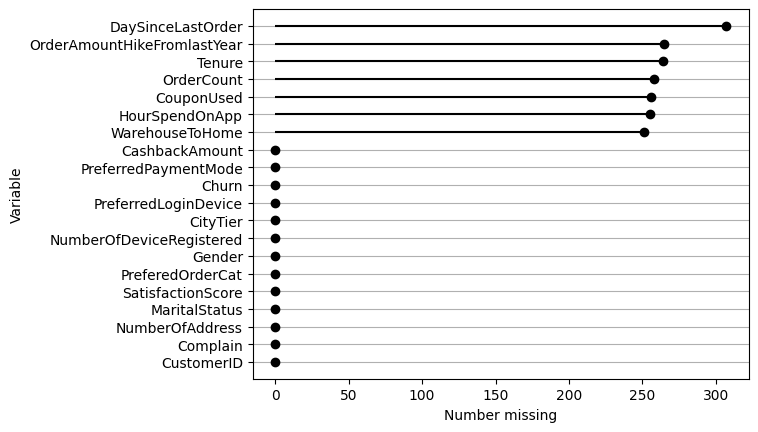

In [9]:
ecommerce_df.missing.missing_variable_plot()

## 06. IMPUTACIÓN DE DATOS FALTANTES

In [10]:
import missingno

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: >

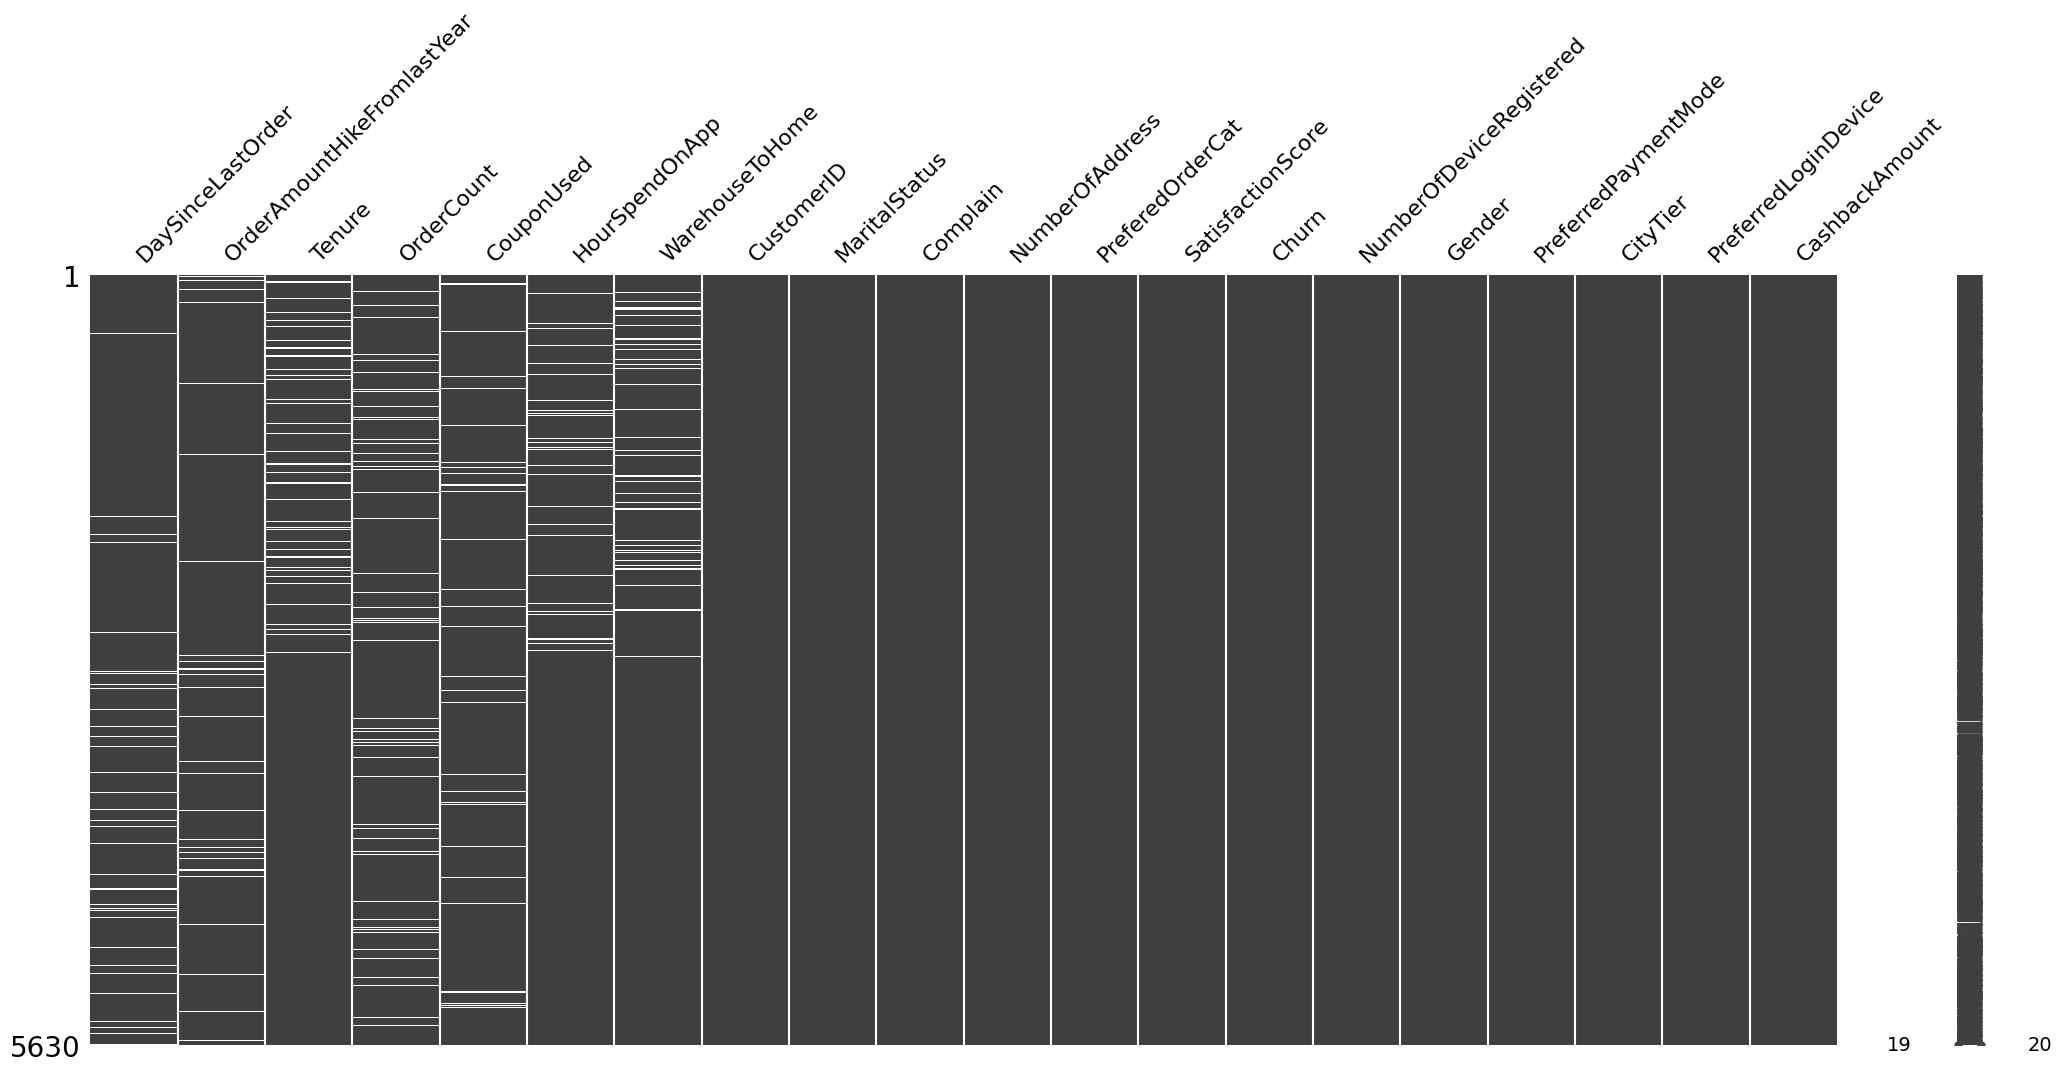

In [11]:
(
    ecommerce_df
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)

El método a utilizar para la imputación será en base a la media ya que todos las variables son numéricas:

### 06.1. IMPUTACIÓN DE DaySinceLastOrder:

In [12]:
df_day_since_last_order = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [13]:
df_day_since_last_order['DaySinceLastOrder'] = df_day_since_last_order['DaySinceLastOrder'].fillna(df_day_since_last_order['DaySinceLastOrder'].mean())
sorted_day_df = df_day_since_last_order.sort_values(
    by=['DaySinceLastOrder'],
    ascending=False
)
sorted_day_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
2040,52041,1,0.0,Mobile Phone,3,6.0,Debit Card,Male,2.0,4,Fashion,3,Married,6,0,11.0,5.0,11.0,46.0,206
4305,54306,0,4.0,Mobile Phone,1,12.0,COD,Female,3.0,4,Mobile Phone,5,Married,7,0,15.0,1.0,3.0,31.0,157
1490,51491,0,3.0,Phone,1,11.0,COD,Female,2.0,3,Mobile,5,Married,6,0,14.0,0.0,2.0,30.0,132
3076,53077,0,11.0,Mobile Phone,1,21.0,Debit Card,Female,4.0,4,Mobile Phone,5,Married,3,0,13.0,4.0,13.0,18.0,155
3565,53566,0,18.0,Mobile Phone,1,36.0,UPI,Male,3.0,4,Laptop & Accessory,2,Single,3,0,26.0,2.0,2.0,18.0,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,51363,0,0.0,Computer,1,22.0,CC,Male,NaN,1,Mobile,1,Married,2,1,13.0,0.0,1.0,0.0,129
1902,51903,0,8.0,Computer,1,8.0,Debit Card,Female,3.0,3,Laptop & Accessory,5,Married,3,0,11.0,1.0,1.0,0.0,151
573,50574,0,8.0,Phone,3,24.0,Credit Card,Female,2.0,3,Laptop & Accessory,3,Divorced,2,0,16.0,1.0,1.0,0.0,146
260,50261,1,NaN,Computer,1,10.0,COD,Male,2.0,3,Mobile,2,Single,19,1,23.0,1.0,1.0,0.0,123


In [14]:
print(f'Media original : {ecommerce_df["DaySinceLastOrder"].mean()} | Media sin nulos: {df_day_since_last_order["DaySinceLastOrder"].mean()}')

Media original : 4.543490512868683 | Media sin nulos: 4.543490512868684


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 06.2. IMPUTACIÓN DE OrderAmountHikeFromlastYear:

In [15]:
df_order_amount_hike = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [16]:
df_order_amount_hike['OrderAmountHikeFromlastYear'] = df_order_amount_hike['OrderAmountHikeFromlastYear'].fillna(df_order_amount_hike['OrderAmountHikeFromlastYear'].mean())
sorted_order_amount_df = df_order_amount_hike.sort_values(
    by=['OrderAmountHikeFromlastYear'],
    ascending=False
)
sorted_order_amount_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
3761,53762,0,23.0,Mobile Phone,1,10.0,Credit Card,Female,3.0,5,Laptop & Accessory,5,Divorced,6,0,26.0,2.0,2.0,3.0,173
5235,55236,0,6.0,Mobile Phone,1,17.0,Credit Card,Male,4.0,4,Fashion,1,Single,4,0,26.0,1.0,NaN,1.0,237
5247,55248,0,8.0,Phone,3,14.0,COD,Male,3.0,4,Mobile Phone,3,Married,2,1,26.0,4.0,6.0,8.0,148
3366,53367,0,9.0,Mobile Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165
2868,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1648,51649,0,4.0,Mobile Phone,3,13.0,COD,Male,3.0,1,Laptop & Accessory,1,Married,5,0,11.0,3.0,7.0,7.0,169
1658,51659,0,6.0,Computer,1,11.0,Debit Card,Female,3.0,3,Fashion,4,Married,7,0,11.0,7.0,8.0,NaN,219
1664,51665,0,5.0,Mobile Phone,3,14.0,COD,Female,3.0,4,Laptop & Accessory,4,Married,2,1,11.0,11.0,11.0,9.0,152
1665,51666,0,0.0,Phone,3,8.0,Debit Card,Male,3.0,3,Laptop & Accessory,3,Single,2,1,11.0,0.0,1.0,4.0,145


In [17]:
print(f'Media original : {ecommerce_df["OrderAmountHikeFromlastYear"].mean()} | Media sin nulos: {df_order_amount_hike["OrderAmountHikeFromlastYear"].mean()}')

Media original : 15.707921714818266 | Media sin nulos: 15.707921714818266


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 06.3. IMPUTACIÓN DE OrderCount:

In [18]:
df_order_count = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [19]:
df_order_count['OrderCount'] = df_order_count['OrderCount'].fillna(df_order_count['OrderCount'].mean())
sorted_order_count_df = df_order_count.sort_values(
    by=['OrderCount'],
    ascending=False
)
sorted_order_count_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4338,54339,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,9.0,16.0,NaN,230
3604,53605,0,29.0,Computer,1,15.0,Credit Card,Male,3.0,5,Grocery,4,Married,3,1,16.0,4.0,16.0,1.0,261
5097,55098,0,13.0,Mobile Phone,1,20.0,Credit Card,Female,4.0,5,Grocery,4,Married,8,1,NaN,11.0,16.0,3.0,296
5074,55075,0,29.0,Computer,1,15.0,Credit Card,Male,3.0,5,Grocery,4,Married,3,1,16.0,3.0,16.0,1.0,261
3627,53628,0,13.0,Mobile Phone,1,20.0,Credit Card,Female,4.0,5,Grocery,4,Married,8,1,NaN,14.0,16.0,3.0,296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1816,51817,0,11.0,Mobile Phone,1,16.0,Credit Card,Female,3.0,3,Laptop & Accessory,3,Married,4,0,19.0,0.0,1.0,0.0,198
1818,51819,0,22.0,Mobile Phone,1,24.0,Debit Card,Male,2.0,4,Others,3,Married,2,1,NaN,1.0,1.0,9.0,295
1819,51820,0,0.0,Phone,1,29.0,CC,Male,NaN,1,Mobile,1,Married,2,1,11.0,0.0,1.0,4.0,127
1820,51821,0,0.0,Mobile Phone,3,34.0,E wallet,Male,3.0,3,Laptop & Accessory,4,Married,2,0,20.0,0.0,1.0,4.0,163


In [20]:
print(f'Media original : {ecommerce_df["OrderCount"].mean()} | Media sin nulos: {df_order_count["OrderCount"].mean()}')

Media original : 3.0080044676098288 | Media sin nulos: 3.0080044676098288


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 06.4. IMPUTACIÓN DE CouponUsed:

In [21]:
df_coupon_used = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [22]:
df_coupon_used['CouponUsed'] = df_coupon_used['CouponUsed'].fillna(df_coupon_used['CouponUsed'].mean())
sorted_coupon_used_df = df_coupon_used.sort_values(
    by=['OrderCount'],
    ascending=False
)
sorted_coupon_used_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
3442,53443,1,1.0,Mobile Phone,1,23.0,Debit Card,Female,3.0,2,Mobile Phone,5,Single,3,0,17.0,16.0,16.0,15.0,152
5086,55087,0,17.0,Mobile Phone,3,11.0,E wallet,Female,3.0,5,Fashion,1,Single,5,0,15.0,11.0,16.0,NaN,227
4338,54339,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,9.0,16.0,NaN,230
4286,54287,1,21.0,Mobile Phone,1,30.0,Credit Card,Female,4.0,4,Fashion,1,Married,3,0,13.0,8.0,16.0,NaN,228
3551,53552,0,20.0,Mobile Phone,3,9.0,E wallet,Female,4.0,4,Grocery,5,Divorced,10,0,NaN,13.0,16.0,10.0,295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,55566,0,5.0,Computer,1,17.0,Credit Card,Female,3.0,4,Fashion,3,Married,6,0,21.0,4.0,NaN,9.0,235
5581,55582,0,21.0,Computer,1,8.0,Credit Card,Female,4.0,4,Fashion,4,Married,2,0,19.0,1.0,NaN,13.0,245
5590,55591,0,12.0,Mobile Phone,1,17.0,Credit Card,Female,4.0,6,Fashion,3,Married,5,0,13.0,1.0,NaN,12.0,257
5621,55622,1,14.0,Mobile Phone,3,35.0,E wallet,Male,3.0,5,Fashion,5,Married,6,1,14.0,3.0,NaN,1.0,234


In [23]:
print(f'Media original : {ecommerce_df["CouponUsed"].mean()} | Media sin nulos: {df_coupon_used["CouponUsed"].mean()}')

Media original : 1.7510234462225531 | Media sin nulos: 1.7510234462225531


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 06.5. IMPUTACIÓN DE HourSpendOnApp:

In [24]:
df_hour_spend = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [25]:
df_hour_spend['HourSpendOnApp'] = df_hour_spend['HourSpendOnApp'].fillna(df_hour_spend['HourSpendOnApp'].mean())
sorted_hour_spend_df = df_hour_spend.sort_values(
    by=['HourSpendOnApp'],
    ascending=False
)
sorted_hour_spend_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4248,54249,0,4.0,Mobile Phone,1,9.0,Debit Card,Male,5.0,5,Laptop & Accessory,1,Married,3,0,20.0,4.0,11.0,9.0,167
4351,54352,0,1.0,Phone,1,16.0,Credit Card,Female,5.0,4,Mobile Phone,4,Single,3,0,17.0,1.0,2.0,4.0,148
4223,54224,0,31.0,Mobile Phone,3,32.0,Debit Card,Female,5.0,4,Fashion,5,Single,9,0,12.0,7.0,8.0,10.0,201
4162,54163,1,1.0,Phone,1,9.0,UPI,Male,4.0,5,Mobile Phone,3,Single,8,1,16.0,1.0,2.0,1.0,146
4142,54143,1,14.0,Computer,3,7.0,Debit Card,Male,4.0,4,Laptop & Accessory,3,Married,9,0,13.0,2.0,2.0,2.0,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,50048,0,NaN,Computer,1,9.0,CC,Male,1.0,3,Mobile,4,Single,5,0,12.0,4.0,7.0,2.0,121
2212,52213,0,23.0,Computer,1,8.0,Credit Card,Female,1.0,3,Grocery,5,Married,3,0,22.0,NaN,2.0,2.0,279
150,50151,0,10.0,Computer,1,6.0,Credit Card,Female,0.0,3,Fashion,2,Married,3,1,18.0,0.0,NaN,2.0,236
1950,51951,0,11.0,Computer,1,18.0,Debit Card,Male,0.0,4,Laptop & Accessory,5,Married,3,0,15.0,1.0,1.0,2.0,163


In [26]:
print(f'Media original : {ecommerce_df["HourSpendOnApp"].mean()} | Media sin nulos: {df_hour_spend["HourSpendOnApp"].mean()}')

Media original : 2.9315348837209303 | Media sin nulos: 2.9315348837209303


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 06.6. IMPUTACIÓN DE WarehouseToHome:

In [27]:
df_warehouse_to_home = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [28]:
df_warehouse_to_home['WarehouseToHome'] = df_warehouse_to_home['WarehouseToHome'].fillna(df_warehouse_to_home['WarehouseToHome'].mean())
sorted_warehouse_to_home_df = df_warehouse_to_home.sort_values(
    by=['WarehouseToHome'],
    ascending=False
)
sorted_warehouse_to_home_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
4124,54125,0,26.0,Computer,3,127.0,Debit Card,Male,3.0,4,Mobile Phone,1,Married,4,0,16.0,2.0,2.0,1.0,160
1309,51310,0,25.0,Computer,3,126.0,Debit Card,Male,2.0,3,Mobile,1,Married,3,0,15.0,1.0,1.0,0.0,135
3727,53728,0,19.0,Mobile Phone,1,36.0,Cash on Delivery,Male,3.0,4,Fashion,1,Divorced,6,1,19.0,2.0,2.0,NaN,219
3438,53439,1,1.0,Computer,3,36.0,Credit Card,Male,4.0,6,Laptop & Accessory,5,Single,10,0,19.0,1.0,3.0,3.0,175
2889,52890,0,12.0,Mobile Phone,1,36.0,COD,Male,3.0,4,Laptop & Accessory,2,Divorced,5,0,19.0,1.0,2.0,8.0,188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1401,51402,0,8.0,Computer,3,5.0,Debit Card,Male,3.0,3,Fashion,5,Married,2,0,22.0,0.0,1.0,8.0,191
451,50452,0,2.0,Computer,3,5.0,E wallet,Male,2.0,3,Laptop & Accessory,2,Divorced,1,0,19.0,0.0,1.0,1.0,143
1001,51002,0,23.0,Mobile Phone,3,5.0,E wallet,Male,2.0,3,Others,3,Married,5,1,NaN,0.0,1.0,0.0,293
3490,53491,1,1.0,Computer,1,5.0,Credit Card,Male,3.0,5,Mobile Phone,4,Married,3,0,16.0,1.0,2.0,1.0,151


In [29]:
print(f'Media original : {ecommerce_df["WarehouseToHome"].mean()} | Media sin nulos: {df_warehouse_to_home["WarehouseToHome"].mean()}')

Media original : 15.639895891429633 | Media sin nulos: 15.639895891429632


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 06.7. IMPUTACIÓN DE Tenure

Como no se puede determinar la incidencia de la variable "Tenure", se realizó un análisis de regresión lineal y logística:

#### a) Regresión Lineal:

In [36]:
df_tenure = ecommerce_df.copy()
df_tenure.dropna(inplace=True)
df_tenure.head(5)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139
11,50012,1,11.0,Mobile Phone,1,6.0,Debit Card,Male,3.0,4,Fashion,3,Single,10,1,13.0,0.0,1.0,0.0,154
12,50013,1,0.0,Phone,1,11.0,COD,Male,2.0,3,Mobile,3,Single,2,1,13.0,2.0,2.0,2.0,134


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Axes: xlabel='Tenure', ylabel='Churn'>

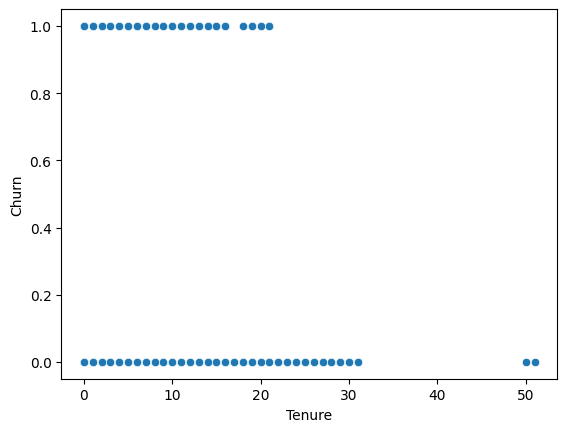

In [37]:
sns.scatterplot(
    data=df_tenure,
    x='Tenure',
    y='Churn'
)

#### b) Regresión Logística:

In [38]:
import statsmodels.formula.api as smf
smf.logit(
    formula='Churn ~ Tenure',
    data=df_tenure
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.368348
         Iterations 7


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 3774
Model:                          Logit   Df Residuals:                     3772
Method:                           MLE   Df Model:                            1
Date:                Sat, 15 Feb 2025   Pseudo R-squ.:                  0.1840
Time:                        19:57:49   Log-Likelihood:                -1390.1
converged:                       True   LL-Null:                       -1703.6
Covariance Type:            nonrobust   LLR p-value:                2.275e-138
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3379      0.064     -5.299      0.000      -0.463      -0.213
Tenure        -0.2274      0.012    -18.780      0.000      -0.251      -0.204
==============================================================================
"""

Se puede apreciar que en ambos modelos de regresión no tienen relación fuerte con la variable "Churn" en tal sentido, no se realizará una imputación y solo se eliminarán los nulos.

## 07. LIMPIEZA DE LA DATA

### 07.1. CONSOLIDACIÓN DE LAS IMPUTACIONES EN UNA SOLA DATA:

In [39]:
ecommerce_processed_df = ecommerce_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [40]:
ecommerce_processed_df['DaySinceLastOrder'] = ecommerce_processed_df['DaySinceLastOrder'].fillna(ecommerce_processed_df['DaySinceLastOrder'].mean())
ecommerce_processed_df['OrderAmountHikeFromlastYear'] = ecommerce_processed_df['OrderAmountHikeFromlastYear'].fillna(ecommerce_processed_df['OrderAmountHikeFromlastYear'].mean())
ecommerce_processed_df['OrderCount'] = ecommerce_processed_df['OrderCount'].fillna(ecommerce_processed_df['OrderCount'].mean())
ecommerce_processed_df['CouponUsed'] = ecommerce_processed_df['CouponUsed'].fillna(ecommerce_processed_df['CouponUsed'].mean())
ecommerce_processed_df['HourSpendOnApp'] = ecommerce_processed_df['HourSpendOnApp'].fillna(ecommerce_processed_df['HourSpendOnApp'].mean())
ecommerce_processed_df['WarehouseToHome'] = ecommerce_processed_df['WarehouseToHome'].fillna(ecommerce_processed_df['WarehouseToHome'].mean())

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### 07.2. ELIMINACIÓN DE NULOS:

In [41]:
print(f'Total de valores: {ecommerce_processed_df.size}')
print(f'Total de valores missing: {ecommerce_processed_df.missing.number_missing()}')
print(f'Total de valores completos: {ecommerce_processed_df.missing.number_complete()}')

Total de valores: 112600
Total de valores missing: 264
Total de valores completos: 112336


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [43]:
ecommerce_processed_df.missing.missing_variable_summary()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,variable,n_missing,n_cases,pct_missing
0,CustomerID,0,5630,0.000000
1,Churn,0,5630,0.000000
2,Tenure,264,5630,4.689165
3,PreferredLoginDevice,0,5630,0.000000
4,CityTier,0,5630,0.000000
5,WarehouseToHome,0,5630,0.000000
6,PreferredPaymentMode,0,5630,0.000000
7,Gender,0,5630,0.000000
8,HourSpendOnApp,0,5630,0.000000
9,NumberOfDeviceRegistered,0,5630,0.000000


In [44]:
ecommerce_final_df = ecommerce_processed_df.copy()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [47]:
ecommerce_final_df.dropna(inplace=True)
ecommerce_final_df.missing.missing_variable_summary()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,variable,n_missing,n_cases,pct_missing
0,CustomerID,0,5366,0.0
1,Churn,0,5366,0.0
2,Tenure,0,5366,0.0
3,PreferredLoginDevice,0,5366,0.0
4,CityTier,0,5366,0.0
5,WarehouseToHome,0,5366,0.0
6,PreferredPaymentMode,0,5366,0.0
7,Gender,0,5366,0.0
8,HourSpendOnApp,0,5366,0.0
9,NumberOfDeviceRegistered,0,5366,0.0


## 08. CODIFICACIÓN DE DATOS CATEGORICOS

In [48]:
ecommerce_final_df.dtypes

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [49]:
ecommerce_final_df.dtypes.value_counts()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
int64,8
float64,7
object,5


### 08.1. VERIFICACIÓN DE CATEGORIAS DE CADA VARIABLE CATEGORICA:

In [50]:
ecommerce_final_df['PreferredLoginDevice'].value_counts()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
PreferredLoginDevice,
Mobile Phone,2732
Computer,1552
Phone,1082


In [51]:
ecommerce_final_df['PreferredPaymentMode'].value_counts()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
PreferredPaymentMode,
Debit Card,2208
Credit Card,1493
E wallet,601
UPI,391
COD,355
CC,193
Cash on Delivery,125


In [52]:
ecommerce_final_df['Gender'].value_counts()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
Gender,
Male,3217
Female,2149


In [53]:
ecommerce_final_df['PreferedOrderCat'].value_counts()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
PreferedOrderCat,
Laptop & Accessory,2039
Mobile Phone,1227
Fashion,826
Mobile,600
Grocery,410
Others,264


In [54]:
ecommerce_final_df['MaritalStatus'].value_counts()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count
MaritalStatus,
Married,2856
Single,1699
Divorced,811


### 08.2. PREPARACIÓN PREVIA DE LA DATA

In [56]:
ecommerce_raw_df = (
    ecommerce_final_df
    .clean_names(
        case_type="snake"
    )
)
ecommerce_raw_df.head(2)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,customer_id,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134


In [59]:
eco_df = (
    ecommerce_raw_df
    .rename_columns(
        {
            "preferred_login_device": "login_device",
            "warehouse_to_home": "lead_time",
            "preferred_payment_mode": "payment_mode",
            "hour_spend_on_app": "app_usage",
            "number_of_device_registered": "device_count",
            "prefered_order_cat": "order_category",
            "order_amount_hike_fromlast_year": "amount_hike",
            "day_since_last_order": "last_order"
        }
    )
)
eco_df.head(5)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,customer_id,churn,tenure,login_device,city_tier,lead_time,payment_mode,gender,app_usage,device_count,order_category,satisfaction_score,marital_status,number_of_address,complain,amount_hike,coupon_used,order_count,last_order,cashback_amount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.000000,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.000000,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,2.931535,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.000000,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,2.931535,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,127


### 08.3. CODIFICACIÓN CON SKLEARN Y ONE HOT:

De las 5 variables categoricas se realizará la codificación ordinal de: Login_Device, Payment_Mode, Gender y Marital_Status, con SKLEARN.

#### a) CREACIÓN DEL TRANSFORMADOR:

In [60]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), ['login_device', 'payment_mode', 'gender', 'marital_status']),
    (sklearn.preprocessing.OneHotEncoder(), ['order_category']),
    remainder='passthrough'
)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### b) APLICACIÓN DEL TRANSFORMADOR:

In [62]:
eco_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(eco_df),
        columns=transformer.get_feature_names_out(),
        index=eco_df.index
    )
    .rename_columns(
        function = lambda x: x.removeprefix("ordinalencoder__")
    )
    .rename_columns(
        function = lambda x: x.removeprefix("onehotencoder__order_category_")
    )
    .rename_columns(
        function = lambda x: x.removeprefix("remainder__")
    )
)
eco_transformed_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.11/dist-packages/pandas_flavor/register.py:157: FutureWarning: This function will be deprecated in a 1.x release. Please use `pd.DataFrame.rename` instead.
  return method(self._obj, *args, **kwargs)


,login_device,payment_mode,gender,marital_status,Fashion,Grocery,Laptop & Accessory,Mobile,Mobile Phone,Others,customer_id,churn,tenure,city_tier,lead_time,app_usage,device_count,satisfaction_score,number_of_address,complain,amount_hike,coupon_used,order_count,last_order,cashback_amount
0,1.0,4.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,50001.0,1.0,4.0,3.0,6.0,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.000000,160.0
3,2.0,4.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,50004.0,1.0,0.0,3.0,15.0,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.000000,134.0
4,2.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,50005.0,1.0,0.0,1.0,12.0,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.000000,130.0
5,0.0,4.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,50006.0,1.0,0.0,1.0,22.0,3.000000,5.0,5.0,2.0,1.0,22.0,4.0,6.0,7.000000,139.0
8,2.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,50009.0,1.0,13.0,3.0,9.0,2.931535,4.0,3.0,2.0,1.0,14.0,0.0,1.0,2.000000,127.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,55626.0,0.0,10.0,1.0,30.0,3.000000,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.000000,151.0
5626,1.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,55627.0,0.0,13.0,1.0,13.0,3.000000,5.0,5.0,6.0,0.0,16.0,1.0,2.0,4.543491,225.0
5627,1.0,4.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,55628.0,0.0,1.0,1.0,11.0,3.000000,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.000000,186.0
5628,0.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,55629.0,0.0,23.0,3.0,9.0,4.000000,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.000000,179.0
